# 1 - Importation des libraries et DataFrames



In [231]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [232]:
companies = pd.read_csv("companies.csv")
dates = pd.read_csv("dates.csv")
funding = pd.read_csv("funding.csv")
industries = pd.read_csv("industries.csv")

In [233]:
con = duckdb.connect()
con.register("companies", companies)
con.register("dates", dates)
con.register("funding", funding)
con.register("industries", industries)

# 2 - Nettoyage des données : valeurs nulles/duppliquées

In [235]:
companies.isnull().sum()

index          0
company_id     0
company        0
city          16
country        0
continent      0
dtype: int64

* Remplacement des valeurs nulles par N/A :

In [236]:
companies["city"] = companies["city"].fillna("N/A")

In [237]:
dates.isnull().sum()

index           0
company_id      0
date_joined     0
year_founded    0
dtype: int64

In [238]:
funding.isnull().sum()

index               0
company_id          0
valuation           0
funding             0
select_investors    1
dtype: int64

* Remplacement des valeurs nulles par N/A :

In [239]:
funding["city"] = funding["select_investors"].fillna("N/A")

In [240]:
companies.duplicated().sum()

np.int64(0)

In [241]:
funding.duplicated().sum()

np.int64(0)

In [242]:
industries.duplicated().sum()

np.int64(0)

# 3 - Exploration des données et statistique descriptive

* Top 10 des pays avec le plus de compagnies :

In [270]:
top_10_countries_companies = (
    companies
    .groupby(["continent", "country"], as_index=False)
    .agg(nb_companies=("company_id", "count"))
    .sort_values("nb_companies", ascending=False)
)
top_10_pays_companies.head(10)


,continent,country,nb_companies
41,North America,United States,562
3,Asia,China,173
5,Asia,India,65
36,Europe,United Kingdom,43
25,Europe,Germany,26
24,Europe,France,24
7,Asia,Israel,20
39,North America,Canada,19
44,South America,Brazil,16
11,Asia,Singapore,12


* Top 10 des investisseurs :

In [244]:
top_10_investors_funding = (
     funding
    .groupby("select_investors", as_index=False)
    .agg(total_funding=("funding", "sum"))
    .sort_values("total_funding", ascending=False)
)

top_10_investors_funding.head(10)

,select_investors,total_funding
488,Tiger Global Management,24736000000
424,Sequoia Capital China,24226000000
480,Tencent Holdings,18755000000
445,SoftBank Group,15380000000
37,Andreessen Horowitz,14915000000
11,Accel,14393000000
279,Khosla Ventures,11839000000
193,Founders Fund,9309000000
337,New Enterprise Associates,9091000000
231,Hillhouse Capital Management,8240000000


* Top 10 des industries :

In [271]:
top_10_industries_types = (
    industries
    .groupby("industry", as_index=False)
    .agg(nb_companies=("company_id", "count"))
    .sort_values("nb_companies", ascending=False)
)

top_10_industries_types.head(10)

,industry,nb_companies
7,Fintech,224
10,Internet software & services,205
5,E-commerce & direct-to-consumer,111
0,Artificial intelligence,84
9,Health,74
12,Other,58
13,"Supply chain, logistics, & delivery",57
3,Cybersecurity,50
4,Data management & analytics,41
11,Mobile & telecommunications,38


* Statistique Descriptive :

In [246]:
print(companies.describe())
print(funding.describe())
print(industries.describe())

             index   company_id
count  1074.000000  1074.000000
mean    536.500000   536.500000
std     310.181399   310.181399
min       0.000000     0.000000
25%     268.250000   268.250000
50%     536.500000   536.500000
75%     804.750000   804.750000
max    1073.000000  1073.000000
             index   company_id     valuation       funding
count  1074.000000  1074.000000  1.074000e+03  1.074000e+03
mean    536.500000   536.606145  3.293296e+09  5.444236e+08
std     310.181399   310.017097  6.632028e+09  7.750887e+08
min       0.000000     1.000000  1.000000e+09  0.000000e+00
25%     268.250000   268.250000  1.000000e+09  2.180000e+08
50%     536.500000   536.500000  2.000000e+09  3.650000e+08
75%     804.750000   804.750000  3.000000e+09  6.030000e+08
max    1073.000000  1073.000000  1.000000e+11  1.400000e+10
             index   company_id
count  1074.000000  1074.000000
mean    536.500000   536.500000
std     310.181399   310.181399
min       0.000000     0.000000
25%     268.

# 4 - Analyses SQL 

#### 4-1 - Jointure des tables :

In [275]:
query = """
SELECT
    c.company_id,
    c.company,
    c.city,
    c.country,
    c.continent,
    d.date_joined,
    d.year_founded,
    f.valuation,
    f.funding,
    f.select_investors,
    i.industry
FROM companies AS c
INNER JOIN dates AS d ON c.company_id = d.company_id
INNER JOIN funding AS f ON d.company_id = f.company_id 
INNER JOIN industries AS i on f.company_id = i.company_id
"""

df_joins = con.sql(query).df()
df_joins.head()

,company_id,company,city,country,continent,date_joined,year_founded,valuation,funding,select_investors,industry
0,189,Otto Bock HealthCare,Duderstadt,Germany,Europe,2017-06-24T00:00:00.000,1919,4.000000e+09,0,EQT Partners,Health
1,848,Matrixport,NaN,Singapore,Asia,2021-06-01T00:00:00.000,2019,1.000000e+09,100000000,Dragonfly Captial,Fintech
2,556,Cloudinary,Santa Clara,United States,North America,2022-02-15T00:00:00.000,2011,2.000000e+09,100000000,Blackstone,Internet software & services
3,999,PLACE,Bellingham,United States,North America,2021-11-17T00:00:00.000,2020,1.000000e+09,100000000,Goldman Sachs Asset Management,Internet software & services
4,396,candy.com,New York,United States,North America,2021-10-21T00:00:00.000,2021,2.000000e+09,100000000,Insight Partners,Fintech


#### 4-2 - Top 10 industries par valorisation :

In [259]:
query = """
SELECT
    industry,
    COUNT(*) AS nb_companies,
    AVG(valuation) AS avg_valuation,
    SUM(valuation) AS total_valuation
FROM df_joins
GROUP BY industry
ORDER BY avg_valuation DESC
LIMIT 10;
"""

industries_valuation = con.sql(query).df()

industries_valuation.head(1)

,industry,nb_companies,avg_valuation,total_valuation
0,Other,58,4.344828e+09,2.520000e+11


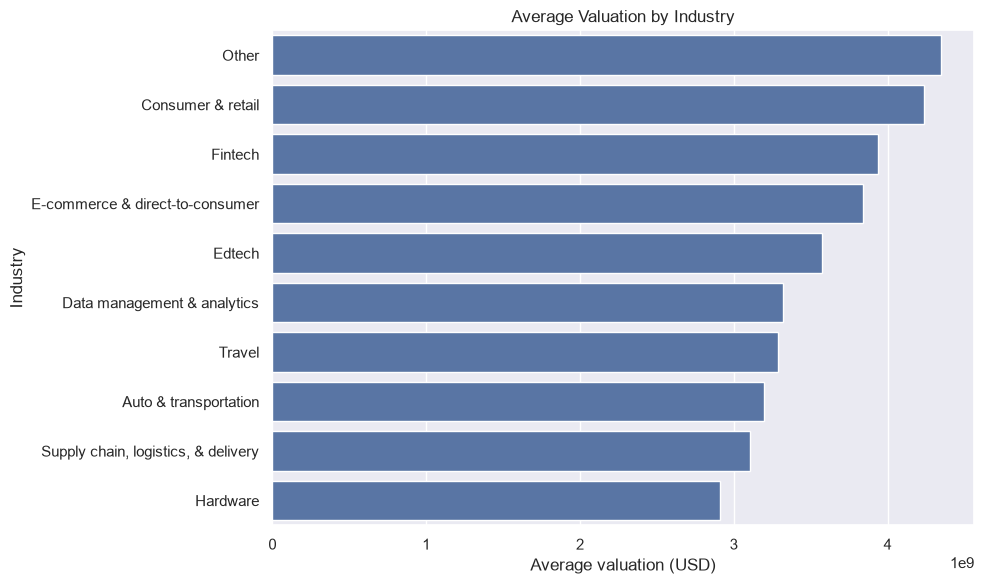

In [272]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=industries_valuation,
    x="avg_valuation",
    y="industry"
)

plt.title("Average Valuation by Industry")
plt.xlabel("Average valuation (USD)")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

#### 4-3 - Top 10 companies :

In [ ]:
query = """
SELECT
    company,
    industry,
    country,
    valuation,
    funding
FROM df_joins
ORDER BY valuation DESC
LIMIT 10;
"""

top_10_companies = con.sql(query).df()

top_10_companies.head(1)

,company,industry,country,valuation,funding
0,SHEIN,E-commerce & direct-to-consumer,China,1.000000e+11,2000000000


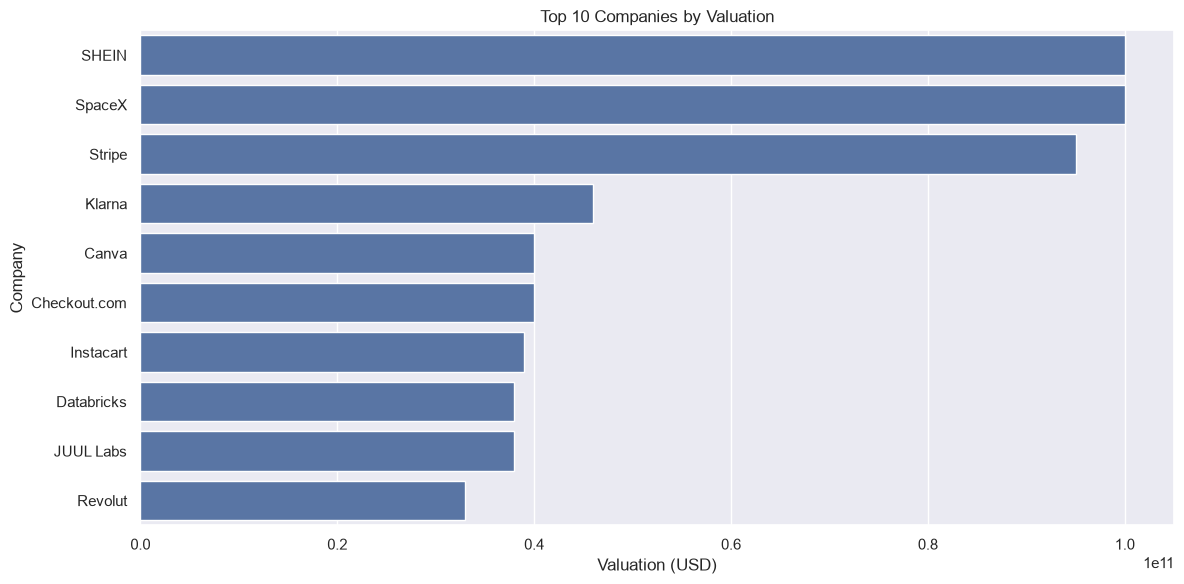

In [273]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10_companies,
    x="valuation",
    y="company"
)

plt.title("Top 10 Companies by Valuation")
plt.xlabel("Valuation (USD)")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

#### 4-4 - Top 3 compagnies par industrie :

In [266]:
query = """
WITH company_ranking AS (

    SELECT
        company,
        industry,
        valuation,
        DENSE_RANK() OVER (
            PARTITION BY industry
            ORDER BY valuation DESC
        ) AS ranking
    FROM df_joins

)

SELECT
    company,
    industry,
    valuation,
    ranking
FROM company_ranking
WHERE ranking <= 2
ORDER BY industry, ranking;
"""

top_companies_by_industry = con.sql(query).df()

top_companies_by_industry.head(1)

,company,industry,valuation,ranking
0,Argo AI,Artificial intelligence,1.200000e+10,1


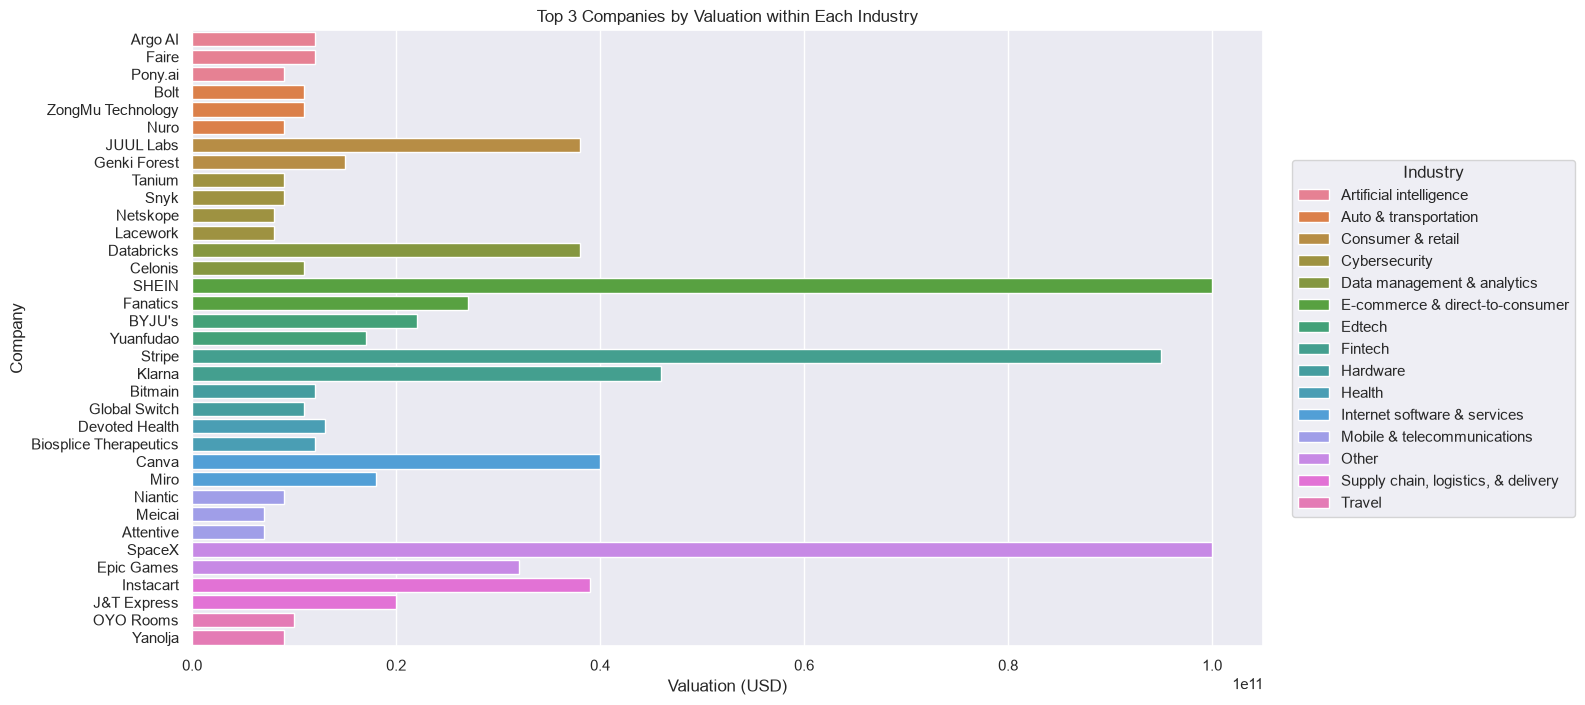

In [ ]:
plt.figure(figsize=(18,8))

sns.barplot(
    data=top_companies_by_industry,
    x="valuation",
    y="company",
    hue="industry"
)

plt.title("Top 3 Companies by Valuation within Each Industry")
plt.xlabel("Valuation (USD)")
plt.ylabel("Company")

plt.legend(
    title="Industry",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.subplots_adjust(right=0.72)  

plt.show()